<a href="https://colab.research.google.com/github/JuliethCanon/Proyecto-NovaRetail-Explorando-factores-de-comportamiento/blob/main/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto NovaRetail+ - Explorando factores de comportamiento


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  

La columna con la variable edad aparece como float64, aunque conceptualmente podría representarse como un valor entero.
No obstante, antes de transformar el tipo de dato, sería recomendable verificar si existen valores decimales válidos.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
numeric_cols = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]
df[numeric_cols].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


Diagnóstico inicial de variables numéricas
Ninguna variable presenta valores nulos.
- `edad` — Se encuentra dentro de rangos esperados, con una variabilidad moderada.
- 'nivel_ingreso' - Presenta una dispersion considerable de ingresos. Alta variabilidad economica
- 'visitas_mes' - Presenta una distribucion Bastante estable
- 'compras_mes' - Observamos una media ligeramente superior a la mediana.
- 'gasto_publicidad_dirigida' - Podria sugerir distintos niveles de inversion publicitaria dependiendo del comportamiento o valor atribuido a cada cliente
- 'Satisfaccion' - Presenta una distribucion estable
- 'ingreso_anual' - Tenemos una diferencia entre media y mediana que puede sugerir un posible sesgo positivo, de valores altos arrastrando el promedio

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df['miembro_premium'].unique()
df['abandono'].unique()

# Verificar distribución de variables binarias

for col in ['miembro_premium', 'abandono']:
    print(f'\n{col}')
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True))


miembro_premium
0    12911
1     2089
Name: miembro_premium, dtype: int64
0    0.860733
1    0.139267
Name: miembro_premium, dtype: float64

abandono
0    12739
1     2261
Name: abandono, dtype: int64
0    0.849267
1    0.150733
Name: abandono, dtype: float64




Diagnóstico inicial de variables binarias
Ambas variables presentan unicamente valores binarios validos.
- `miembro_premium` — Se observa un desbalance importante entre categorias, con un 86% de usuarios que no pertenecen al plan premium, contra un 14%
- `abandono` — Sugiere una tasa de retencion relativamente alta, del 85% de usuarios que no han abandonado la plataforma.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
categorical_cols = ['tipo_dispositivo', 'region']

for col in categorical_cols:
    print(f'\n{col}')
    print(df[col].value_counts())


tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in categorical_cols:
    print(f'\n{col}')
    print(df[col].value_counts(normalize=True))


tipo_dispositivo
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

region
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64



Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Podemos observar que la mayoria de usuarios utilizan la plataforma a traves de su dispositivo movil, con un 65% del total. Seguido de Escritorio cerca del 25%, mientras que tablet tienen una participacion considerablemente menor.
- 'region' - Presenta una distribucion de usuarios equilibrada, con la region norte ligeramente mayor.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

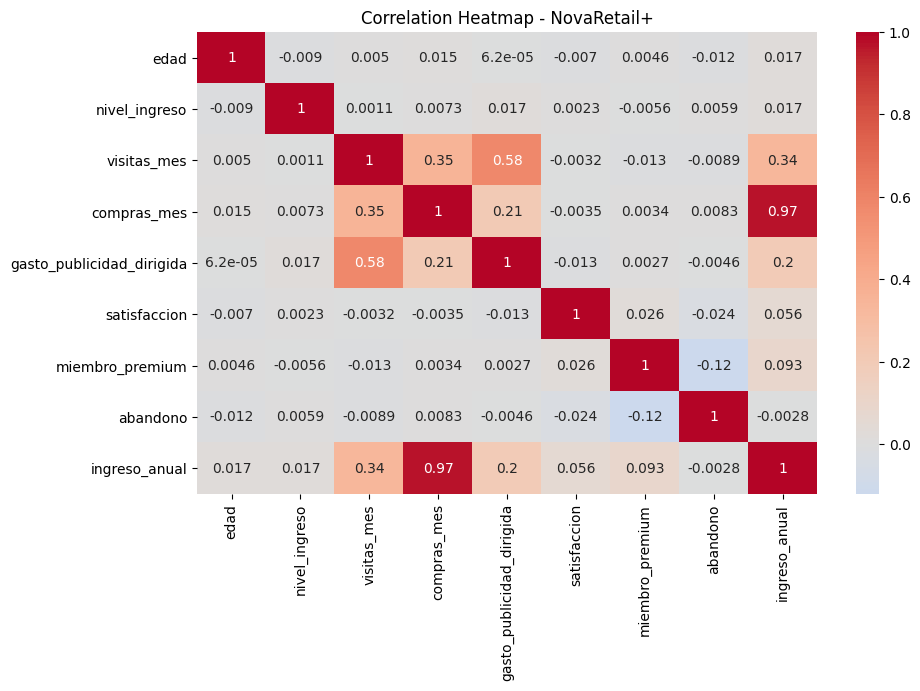

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap - NovaRetail+")
plt.show()





Observaciones generales (Heatmap)  

Diagnóstico inicial de correlaciones

- Se observa una correlación extremadamente alta entre `compras_mes` e `ingreso_anual` (0.97). Esto indica una fuerte colinealidad entre ambas variables. Dado que el ingreso anual representa el ingreso generado por el cliente para la empresa, es coherente que altamente relacionado con la cantidad de compras realizadas mensualmente.

- También se identifica una correlación moderada-alta entre `gasto_publicidad_dirigida` y `visitas_mes` (0.58), lo que podría indicar que una mayor inversión publicitaria está asociada con un incremento en las visitas de los usuarios a la plataforma.

- Existe una correlación moderada entre `visitas_mes` y `compras_mes` (0.35), sugiriendo que los usuarios con mayor actividad en la plataforma tienden a realizar más compras.

- Se observa una correlación negativa débil entre `miembro_premium` y `abandono` (-0.12). Aunque la relación es baja, podría indicar que los usuarios premium tienen una menor tendencia a abandonar la plataforma.

Observaciones respecto a `ingreso_anual`  

- Se observa fuerte colinealidad entre ambas variables.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

No se considera necesario generar un scatterplot general, ya que el heatmap de correlaciones permitió identificar de manera clara las relaciones más relevantes entre variables.

Además, un scatterplot general con múltiples variables podría dificultar la interpretación visual debido a la cantidad de combinaciones posibles. Por esta razón, resulta más útil enfocarse directamente en scatterplots de pares clave con correlaciones moderadas o fuertes para analizar tendencias y patrones específicos.

### Scatterplot para pares clave

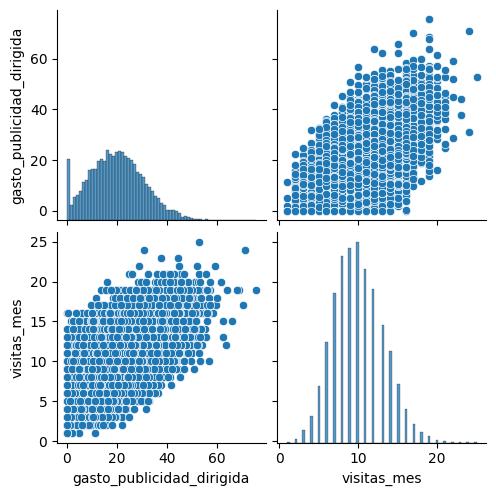

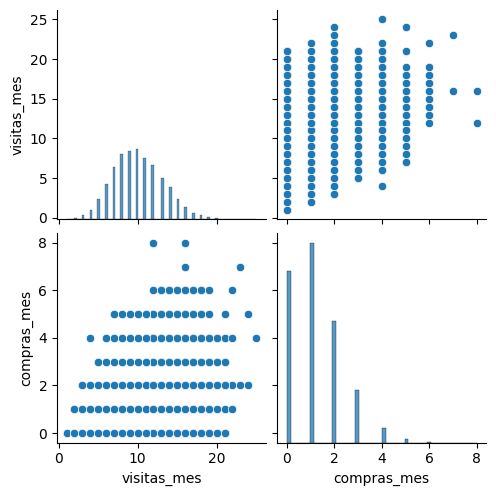

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

sns.pairplot(
    df[
        [
            "gasto_publicidad_dirigida",
            "visitas_mes",
        ]
    ]
)
sns.pairplot(
    df[
        [
            "visitas_mes",
            "compras_mes",
        ]
    ]
)




Observaciones iniciales (Scatterplot)

- gasto_publicidad_dirigida vs visitas_mes:
Se observa una relación positiva moderada entre ambas variables. A medida que aumenta el gasto en publicidad dirigida, también tiende a incrementarse el número de visitas mensuales. La dispersión de los datos es moderada y no se observan outliers extremadamente alejados del comportamiento general.

- visitas_mes vs compras_mes:
También se identifica una relación positiva entre las variables, indicando que los usuarios con mayor número de visitas tienden a realizar más compras mensuales. La dispersión es media-alta, por lo que la relación no es completamente lineal. Existen algunos valores alejados, aunque no parecen representar outliers severos.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
df['gasto_publicidad_dirigida'].corr(
    df['visitas_mes'],
    method='pearson'
)

0.5789472719412827

In [ ]:
# Calcular correlación entre variables relevantes
df['visitas_mes'].corr(
    df['compras_mes'],
    method='spearman'
)

0.33294292722789276




Observaciones de correlación

gasto_publicidad_dirigida vs visitas_mes

- Se utilizó el coeficiente de Pearson debido a que la relación observada en el scatterplot presenta una tendencia relativamente lineal.
- Se obtuvo una correlación positiva moderada de 0.58, lo que indica que un mayor gasto en publicidad dirigida tiende a asociarse con un aumento en las visitas mensuales.
- No se observa colinealidad fuerte entre las variables.

visitas_mes vs compras_mes

- Se utilizó el coeficiente de Spearman debido a que la relación observada presenta mayor dispersión y una tendencia menos lineal.
- Se obtuvo una correlación positiva moderada-baja de 0.33, indicando que los usuarios con más visitas tienden a realizar más compras, aunque la relación no es especialmente fuerte.

- La correlación es consistente con los patrones observados previamente en el heatmap y scatterplot.


### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

pointbiserialr(
    df["miembro_premium"],
    df["ingreso_anual"]
)

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)



Observaciones Punto-biserial

miembro_premium vs ingreso_anual
- Se decidió utilizar `miembro_premium` en lugar de `abandono` porque esta variable resulta más representativa para el objetivo principal del análisis, el cual busca identificar factores asociados al ingreso anual generado por los clientes.

- Se obtuvo una correlación positiva muy débil de 0.093, lo que indica que los usuarios premium tienden a generar ligeramente mayores ingresos anuales para la empresa.

- Sin embargo, la magnitud de la relación es baja y cercana a cero, por lo que la pertenencia al programa premium no parece ser un factor fuertemente asociado al ingreso anual.

- A pesar de ello, la dirección positiva podría sugerir una tendencia leve que podría explorarse junto con otras variables del comportamiento del cliente.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np

tabla = pd.crosstab(
    df["region"],
    df["tipo_dispositivo"]
)

chi2, p, dof, expected = chi2_contingency(tabla)

n = tabla.sum().sum()

In [ ]:
# Aplicar V de Cramér en variables relevantes

cramers_v = np.sqrt(
    chi2 / (n * (min(tabla.shape) -1))
)

cramers_v

0.012378338407739397



Observaciones V de Cramér

region vs tipo_dispositivo

- Se aplicó el coeficiente V de Cramér para analizar la posible asociación entre las variables categóricas `region` y `tipo_dispositivo`.

- Se obtuvo un resultado de 0.012, lo que indica una asociación extremadamente débil entre ambas variables.

- Esto sugiere que el tipo de dispositivo utilizado por los clientes no parece variar significativamente según la región.

- En este análisis inicial no se observa una relación relevante entre ambas variables categóricas.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 —

**Evidencia visual:** Scatterplot entre `gasto_publicidad_dirigida` y `visitas_mes`.  
**Evidencia numérica:** Coeficiente de correlación de Pearson: 0.57

**Interpretación**  
Se observa una relación positiva moderada entre el gasto en publicidad dirigida y las visitas mensuales. Esto sugiere que mayores niveles de inversión publicitaria tienden a asociarse con un incremento en la cantidad de visitas realizadas por los usuarios.

**No podemos afirmar**  
No es posible concluir causalidad directa. El aumento en visitas podría estar influenciado también por otros factores no incluidos en el análisis.

**Implicación de negocio**  
La publicidad dirigida podría estar contribuyendo al aumento de tráfico en la plataforma, por lo que optimizar campañas segmentadas podría ayudar a incrementar la interacción de los usuarios.

### Hallazgo 2 —

**Evidencia visual:**   Scatterplot entre `gasto_publicidad_dirigida` y `visitas_mes`.  
**Evidencia numérica:** Coeficiente de correlación de Spearman: 0.33

**Interpretación**  
Los usuarios con mayor cantidad de visitas mensuales tienden a realizar más compras, aunque la relación observada es moderada y presenta cierta dispersión.

**No podemos afirmar**  
No se puede asegurar que un mayor número de visitas provoque directamente más compras. Existen otros posibles factores relacionados con el comportamiento del cliente.

**Implicación de negocio**  
Incrementar la frecuencia de interacción de los usuarios con la plataforma podría relacionarse con mayores oportunidades de compra.

## Sección 6 - Limitaciones y próximos pasos


### **Limitaciones**
- Las correlaciones encontradas no implican causalidad directa entre variables.

- Este análisis corresponde a una exploración inicial de relaciones entre variables, por lo que se requieren análisis más profundos para validar los hallazgos.

- Algunas relaciones podrían estar influenciadas por variables externas no incluidas en el dataset.

- Existe desbalance en ciertas variables, como `miembro_premium`, donde la mayoría de usuarios pertenece a la categoría no premium. Esto puede afectar algunas interpretaciones comparativas.

- Algunas asociaciones observadas presentan correlaciones moderadas o débiles, por lo que deben interpretarse con cautela antes de tomar decisiones de negocio.

### **Próximos pasos**

### 1. Analizar segmentaciones de usuarios premium y no premium
- Comparar comportamiento de visitas, compras y publicidad dirigida entre ambos grupos.
- Evaluar si las campañas publicitarias impactan de forma diferente según el tipo de usuario.

### 2. Explorar la relación entre satisfacción y abandono
- Analizar si menores niveles de satisfacción se asocian con mayores tasas de abandono.
- Identificar posibles patrones de retención.

### 3. Profundizar el análisis de publicidad dirigida
- Investigar cómo el gasto publicitario se relaciona con compras e ingresos.
- Evaluar si la publicidad está siendo dirigida hacia segmentos con mayor potencial de conversión.
